In [81]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xobjects as xo
import xtrack as xt

from tapering import get_rf_phase

plt.rcParams.update({
    "font.size": 15,
    "axes.labelsize": 17,
    "axes.titlesize": 18,
    "legend.fontsize": 13,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.dpi": 120,
})

LATTICE_FILE = Path("/Users/skostogl/Documents/workspace/workspace_2026/FCC/07_2026/ground_motion_studies/acc-models-fcc-ee/lattices/t/fccee_t_merged_dipoles.json")
LINE_NAME = "fccee_p_ring"
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

print(f"Lattice: {LATTICE_FILE.resolve()}")


Lattice: /Users/skostogl/Documents/workspace/workspace_2026/FCC/07_2026/ground_motion_studies/acc-models-fcc-ee/lattices/t/fccee_t_merged_dipoles.json


## Helper functions

The two cases are loaded independently so that the RF and taper settings from one case cannot contaminate the other. The physical strength associated with a taper value is evaluated as

$$K_j^{\rm applied}=K_j^{0}\left(1+\delta_{{\rm taper},j}\right),$$

where $K_j^0$ is the nominal integrated field, gradient, or sextupole strength. Thus the required change is $\Delta K_j=K_j^0\delta_{{\rm taper},j}$.


In [82]:
def load_radiating_line():
    collider = xt.load(LATTICE_FILE) 
    #xt.Multiline.from_json(str(LATTICE_FILE))
    try:
        source_line = collider[LINE_NAME]
    except (KeyError, TypeError):
        source_line = getattr(collider, LINE_NAME)

    line = source_line.copy()
    line.build_tracker(_context=xo.ContextCpu())
    line.configure_radiation(model="mean")
    return line


def clear_taper(line):
    """Set delta_taper to zero in every element that supports it."""
    for name in line.element_names:
        element = line[name]
        if hasattr(element, "delta_taper"):
            element.delta_taper = 0.0


def get_insertion_element_names(line):
    """Return all elements between the DS--straight transition markers."""
    insertion_names = []
    table = line.get_table()
    names = np.asarray(table.name, dtype=str)
    s = np.asarray(table.s, dtype=float)
    valid = names != '_end_point'
    names, s = names[valid], s[valid]
    s_by_name = dict(zip(names, s))

    for ip in ('ipa', 'ipb', 'ipd', 'ipf', 'ipg', 'iph', 'ipj', 'ipl'):
        start = s_by_name[f'end_ds_start_straight_{ip}']
        end = s_by_name[f'end_straight_start_ds_{ip}']
        mask = ((s >= start) & (s < end)) if start <= end else ((s >= start) | (s < end))
        insertion_names.extend(names[mask])

    return np.unique(np.asarray(insertion_names, dtype=str))


def as_float(value):
    array = np.asarray(value)
    return float(array.flat[0])


def magnetic_rigidity_Tm(line):
    """Reference magnetic rigidity B-rho in T m."""
    p0c_GeV = abs(as_float(line.particle_ref.p0c)) * 1e-9
    q0 = abs(as_float(line.particle_ref.q0))
    return p0c_GeV / (0.299792458 * q0)


def make_strength_table(line, twiss):
    """Return nominal and ideally tapered strengths for the main magnet families."""
    s_by_name = {str(name): float(s) for name, s in zip(twiss.name, twiss.s)}
    brho = magnetic_rigidity_Tm(line)
    rows = []

    definitions = {
        "RBend": ("Dipole", "h", r"$B\\ell$", "T m"),
        "Quadrupole": ("Quadrupole", "k1", r"$G\\ell$", "T"),
        "Sextupole": ("Sextupole", "k2", r"$B''\\ell$", "T/m"),
    }

    for name in line.element_names:
        element = line[name]
        class_name = element.__class__.__name__
        if class_name not in definitions:
            continue

        family, coefficient_name, symbol, unit = definitions[class_name]
        if not hasattr(element, coefficient_name):
            continue

        length = as_float(getattr(element, "length", 0.0))
        coefficient = as_float(getattr(element, coefficient_name))
        delta_taper = as_float(getattr(element, "delta_taper", 0.0))

        nominal_strength = brho * coefficient * length
        ideal_strength = nominal_strength * (1.0 + delta_taper)

        rows.append({
            "name": str(name),
            "s_m": s_by_name.get(str(name), np.nan),
            "family": family,
            "symbol": symbol,
            "unit": unit,
            "delta_taper": delta_taper,
            "nominal_strength": nominal_strength,
            "ideal_strength": ideal_strength,
            "strength_change": ideal_strength - nominal_strength,
        })

    return pd.DataFrame(rows).sort_values("s_m").reset_index(drop=True)


## Calculate the three reference cases

For the no-taper case, all magnet taper values are explicitly cleared and only the RF phase is solved. The insertion-only case restores the ideal element-by-element taper in the insertions while leaving the arcs and dispersion suppressors untapered. For the ideal case, Xsuite determines the local taper and RF compensation throughout the complete ring.


In [83]:
# Case 1: radiation and RF compensation, but no magnet tapering.
line_no_taper = load_radiating_line()
clear_taper(line_no_taper)
rf_no_taper = get_rf_phase(line_no_taper)
twiss_no_taper = line_no_taper.twiss()

# Case 2: ideal element-by-element magnet tapering throughout the ring.
line_ideal = load_radiating_line()
line_ideal.compensate_radiation_energy_loss(delta0="zero_mean")
twiss_ideal = line_ideal.twiss()

# Case 3: restore the ideal taper only in the individually powered insertions.
line_insertion_taper = load_radiating_line()
clear_taper(line_insertion_taper)
insertion_names = get_insertion_element_names(line_insertion_taper)
available_names = set(line_insertion_taper.element_names)
copied_taper = 0
for name in insertion_names:
    if name not in available_names:
        continue
    target = line_insertion_taper[name]
    source = line_ideal[name]
    if hasattr(target, 'delta_taper') and hasattr(source, 'delta_taper'):
        target.delta_taper = as_float(source.delta_taper)
        copied_taper += 1
rf_insertion_taper = get_rf_phase(line_insertion_taper)
twiss_insertion_taper = line_insertion_taper.twiss()

# Confirm that the cases are independent and that no taper leaked into case 1.
max_no_taper = max(
    abs(as_float(getattr(line_no_taper[name], "delta_taper", 0.0)))
    for name in line_no_taper.element_names
)
assert max_no_taper < 1e-15, "The no-taper line contains non-zero delta_taper values."

print(f"B-rho = {magnetic_rigidity_Tm(line_ideal):.6f} T m")
print(f"Maximum |delta_taper| in no-taper case: {max_no_taper:.3e}")
print(f"Restored ideal tapering in {copied_taper} insertion elements.")


Loading line from dict: 100%|██████████| 18995/18995 [00:02<00:00, 7560.15it/s]




Warning! Need second attempt on closed orbit search


/Users/skostogl/Documents/workspace/workspace_2026/FCC/09_2026/tapering/FCCee_tapering/tapering.py:149: RuntimeWarning: RF near its limit (RF phase seed): sin(phase_s) = 0.9017, phase_s = 64.38 deg, 9.8% headroom to crest.
  ratio = _check_rf_headroom(U0 / v0.sum(), "RF phase seed", rf_warn_ratio)
/Users/skostogl/Documents/workspace/workspace_2026/FCC/09_2026/tapering/FCCee_tapering/tapering.py:149: RuntimeWarning: RF near its limit (RF phase seed): sin(phase_s) = 0.9018, phase_s = 64.39 deg, 9.8% headroom to crest.
  ratio = _check_rf_headroom(U0 / v0.sum(), "RF phase seed", rf_warn_ratio)
/Users/skostogl/Documents/workspace/workspace_2026/FCC/09_2026/tapering/FCCee_tapering/tapering.py:115: RuntimeWarning: RF near its limit (get_rf_phase iteration 0): sin(phase_s) = 0.9081, phase_s = 65.24 deg, 9.2% headroom to crest.
  inst_phase = np.arcsin(_check_rf_headroom(egain / v0, context, rf_warn_ratio))
/Users/skostogl/Documents/workspace/workspace_2026/FCC/09_2026/tapering/FCCee_tapering/

Compensating energy loss.
Share energy loss among cavities (repeat until energy loss is zero)
Energy loss: 8_148_214_673.634 eV             
Energy loss: 547_159_865.895 eV             
Energy loss: 39_263_508.462 eV             
Energy loss: 2_830_019.619 eV             
Energy loss: 204_045.916 eV             
Energy loss: 14_712.158 eV             
Energy loss: 1_060.780 eV             
Energy loss: 76.485 eV             
Energy loss: 5.516 eV             
Energy loss: 187_227_640.077 eV             
Energy loss: 30_859_907.299 eV             
Energy loss: -8_193_207.838 eV             
Energy loss: -3_540_866.802 eV             
Energy loss: -2_868.191 eV             
Energy loss: 250_680.922 eV             
Energy loss: 41_550.544 eV             
Energy loss: -10_927.730 eV             
Energy loss: -4_749.635 eV             
Energy loss: -8.289 eV             

  - Set delta_taper
  - Restore cavity voltage and frequency. Set cavity lag


Loading line from dict: 100%|██████████| 18995/18995 [00:02<00:00, 7336.02it/s]


RuntimeError: Particle lost while measuring the energy loss, cannot seed the RF phase. Check that radiation is configured and the lattice is sane.

## Closed orbit and equilibrium energy profile

All three curves include synchrotron radiation and a self-consistent RF phase. The insertion-only curve shows the benefit of applying ideal element-by-element tapering in the insertions while retaining untapered magnets in the arcs and dispersion suppressors.


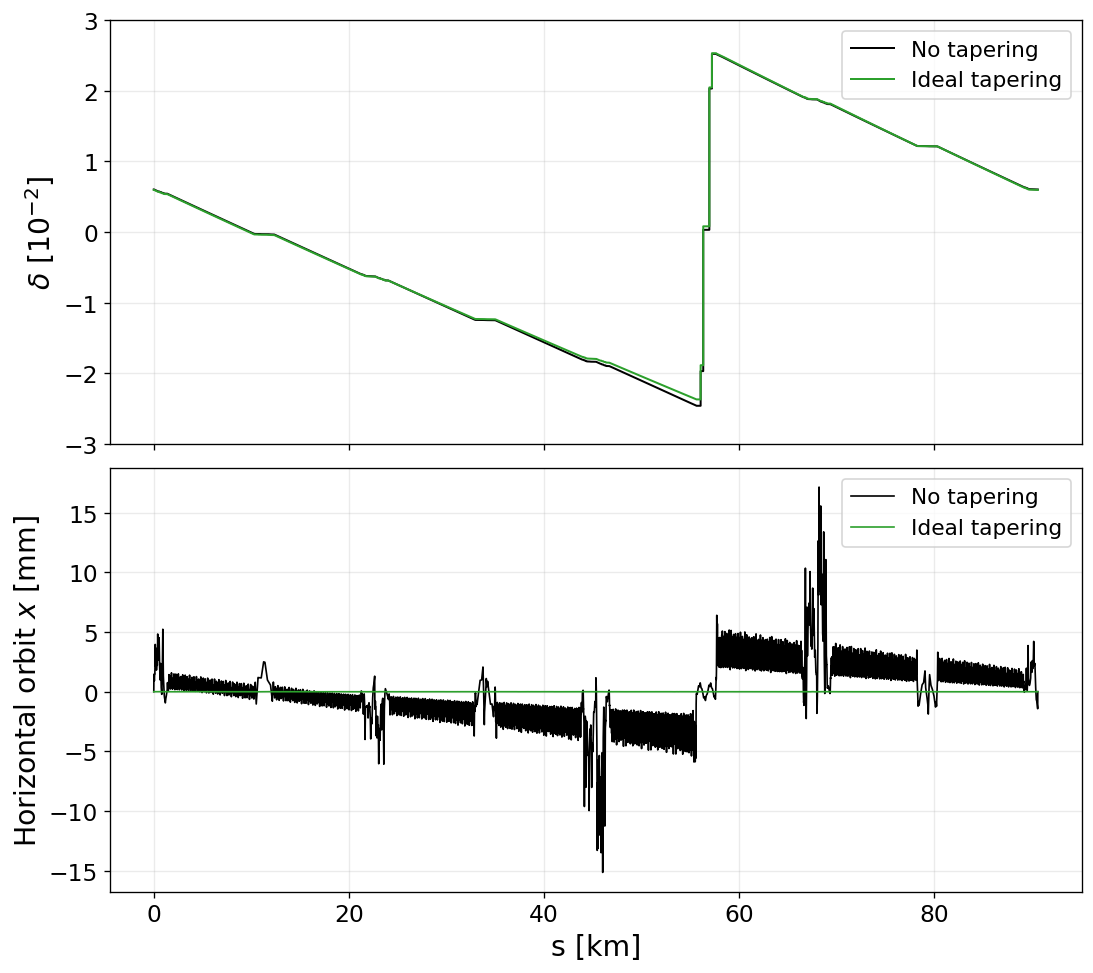

Saved: figures/no_taper_vs_ideal_taper_orbit.png


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, layout="constrained")

s_no_km = np.asarray(twiss_no_taper.s) / 1e3
s_insertion_km = np.asarray(twiss_insertion_taper.s) / 1e3
s_ideal_km = np.asarray(twiss_ideal.s) / 1e3

axes[0].plot(s_insertion_km, np.asarray(twiss_insertion_taper.delta),
             color="tab:blue", lw=1.5, label="Ideal tapering in insertions")
axes[0].plot(s_no_km, np.asarray(twiss_no_taper.delta),
             color="tab:orange", ls="--", lw=1.5, label="No magnet tapering")
axes[0].plot(s_ideal_km, np.asarray(twiss_ideal.delta),
             color="tab:green", ls="--", lw=1.5, label="Ideal tapering")
axes[0].set_ylabel(r"$\Delta p/p_0$")
axes[0].legend(loc="best")

axes[1].plot(s_insertion_km, np.asarray(twiss_insertion_taper.x) * 1e3,
             color="tab:blue", lw=1.5, label="Ideal tapering in insertions")
axes[1].plot(s_no_km, np.asarray(twiss_no_taper.x) * 1e3,
             color="tab:orange", ls="--", lw=1.5, label="No magnet tapering")
axes[1].plot(s_ideal_km, np.asarray(twiss_ideal.x) * 1e3,
             color="tab:green", ls="--", lw=1.5, label="Ideal tapering")
axes[1].set_ylabel(r"Horizontal orbit $x$ [mm]")
axes[1].legend(loc="best")
axes[1].set_xlabel(r"$s$ [km]")

for ax in axes:
    ax.grid(True, alpha=0.25)

figure_path = FIGURE_DIR / "no_taper_vs_ideal_taper_orbit.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {figure_path}")


## Magnet strengths

The left column shows the nominal strength without tapering and the strength required by ideal tapering. The right column shows their difference. The three rows use the appropriate physical units for dipoles, quadrupoles, and sextupoles.


In [ ]:
strengths = make_strength_table(line_ideal, twiss_ideal)
strengths.head()


,name,s_m,family,symbol,unit,delta_taper,nominal_strength,ideal_strength,strength_change
0,qd0ar.0,2.40,Quadrupole,$G\\ell$,T,0.005947,-94.509132,-95.071208,-0.562076
1,qd0br.0,3.25,Quadrupole,$G\\ell$,T,0.005947,-104.629675,-105.251942,-0.622266
2,qd0cr.0,4.60,Quadrupole,$G\\ell$,T,0.005947,-79.237955,-79.709208,-0.471254
3,qf1ar.0,6.60,Quadrupole,$G\\ell$,T,0.005947,29.771019,29.948077,0.177058
4,qf1br.0,7.95,Quadrupole,$G\\ell$,T,0.005947,29.771019,29.948077,0.177058


In [ ]:
strengths["family"].unique()

<ArrowStringArray>
['Quadrupole', 'Dipole', 'Sextupole']
Length: 3, dtype: str

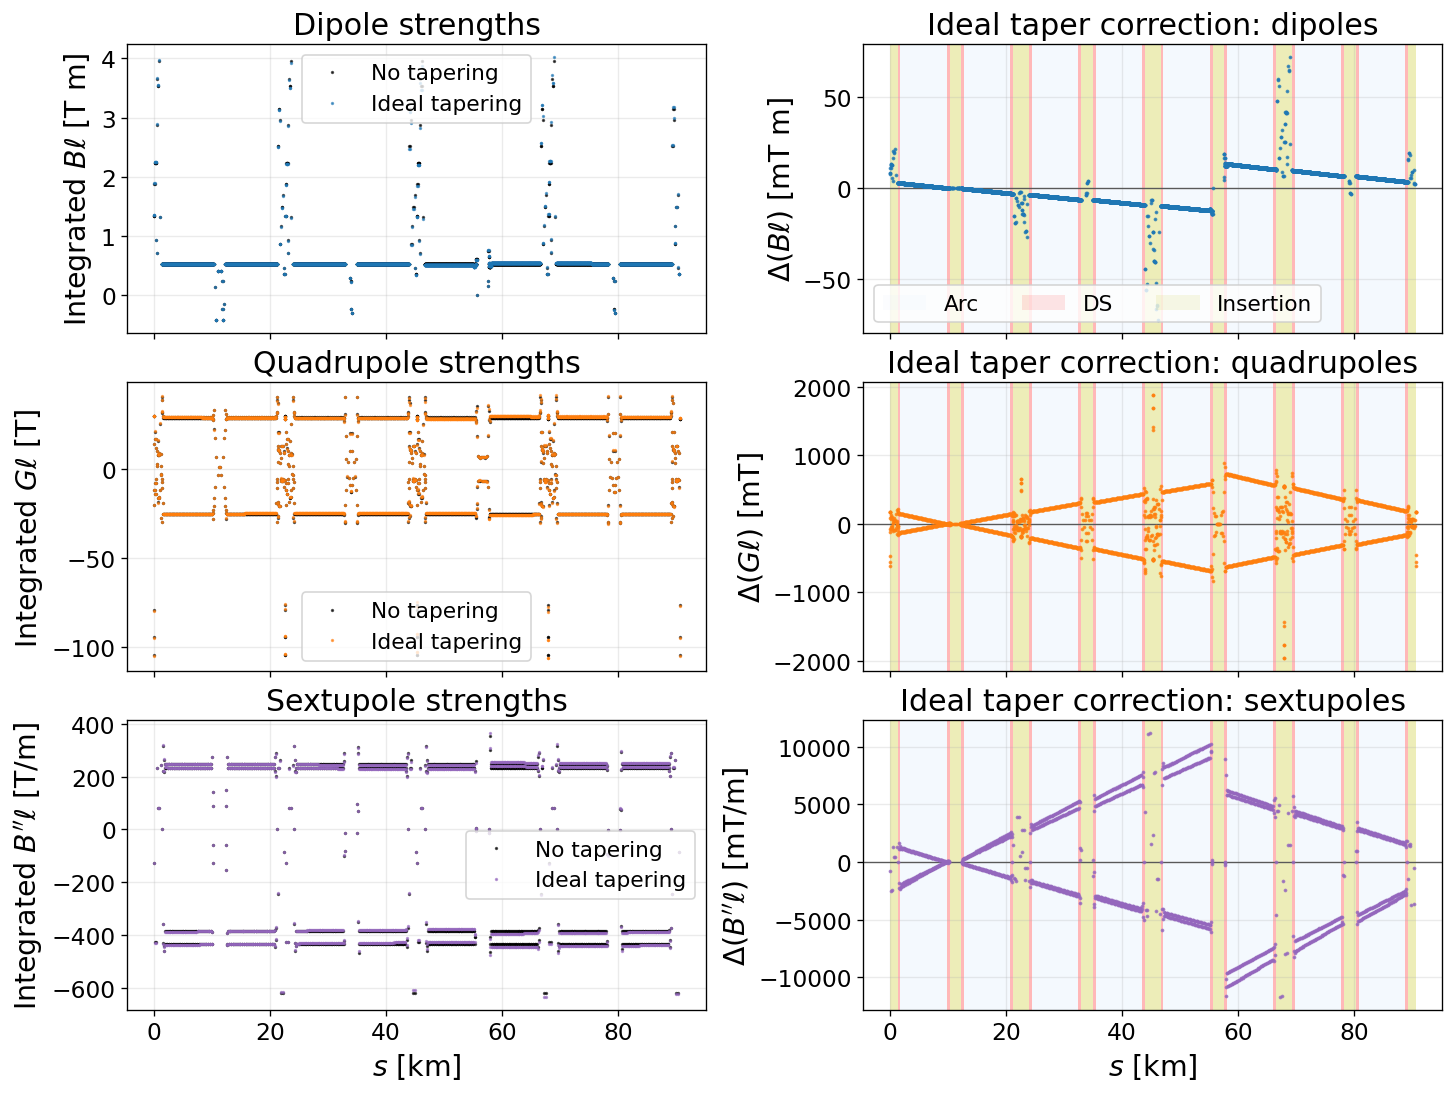

Saved: figures/no_taper_vs_ideal_taper_magnet_strengths.png


In [ ]:
families = [
    ("Dipole", r"Integrated $B\ell$ [T m]", r"$\Delta(B\ell)$ [mT m]", 1e3),
    ("Quadrupole", r"Integrated $G\ell$ [T]", r"$\Delta(G\ell)$ [mT]", 1e3),
    ("Sextupole", r"Integrated $B''\ell$ [T/m]", r"$\Delta(B''\ell)$ [mT/m]", 1e3),
]
colors = {"Dipole": "tab:blue", "Quadrupole": "tab:orange", "Sextupole": "tab:purple"}

# The lattice contains explicit transition markers. The text after `end_`
# identifies the region entered after crossing each marker.
def get_machine_region_spans(twiss):
    transitions = {
        'end_straight_start_ds_': 'DS',
        'end_ds_start_arc_': 'Arc',
        'end_arc_start_ds_': 'DS',
        'end_ds_start_straight_': 'Insertion',
    }
    events = [(0.0, 'Insertion')]
    for name, s_m in zip(twiss.name, twiss.s):
        name = str(name)
        for prefix, region in transitions.items():
            if name.startswith(prefix):
                events.append((float(s_m) / 1e3, region))
                break

    circumference_km = float(twiss.s[-1]) / 1e3
    events = sorted(set(events))
    return [
        (start, events[index + 1][0] if index + 1 < len(events) else circumference_km, region)
        for index, (start, region) in enumerate(events)
    ]

region_spans = get_machine_region_spans(twiss_ideal)
region_colors = {'Arc': '#dbeafe', 'DS': 'r', 'Insertion': 'y'}

fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharex="col", layout="constrained")

for row, (family, absolute_label, change_label, change_scale) in enumerate(families):
    selected = strengths[strengths["family"] == family]
    s_km = selected["s_m"].to_numpy() / 1e3

    axes[row, 0].plot(s_km, selected["nominal_strength"], ".",
                      color="black", ms=2.0, alpha=0.65, label="No tapering")
    axes[row, 0].plot(s_km, selected["ideal_strength"], ".",
                      color=colors[family], ms=2.0, alpha=0.65, label="Ideal tapering")
    axes[row, 0].set_ylabel(absolute_label)
    axes[row, 0].set_title(f"{family} strengths")
    axes[row, 0].legend(loc="best")

    axes[row, 1].plot(s_km, selected["strength_change"] * change_scale, ".",
                      color=colors[family], ms=2.5, alpha=0.75, zorder=3)
    for start_km, end_km, region in region_spans:
        axes[row, 1].axvspan(
            start_km, end_km, color=region_colors[region], alpha=0.28,
            ec='none', zorder=0,
        )
    axes[row, 1].axhline(0.0, color="0.35", lw=0.8)
    axes[row, 1].set_ylabel(change_label)
    axes[row, 1].set_title(f"Ideal taper correction: {family.lower()}s")

    for ax in axes[row]:
        ax.grid(True, alpha=0.25)

axes[-1, 0].set_xlabel(r"$s$ [km]")
axes[-1, 1].set_xlabel(r"$s$ [km]")

from matplotlib.patches import Patch
region_handles = [
    Patch(facecolor=region_colors[region], alpha=0.5, edgecolor='none', label=region)
    for region in ('Arc', 'DS', 'Insertion')
]
axes[0, 1].legend(handles=region_handles, loc='best', ncol=3)

figure_path = FIGURE_DIR / "no_taper_vs_ideal_taper_magnet_strengths.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {figure_path}")


## Relative strength correction and numerical summary

The relative correction is exactly the longitudinal taper profile applied to each magnet. The summary below reports both the closed-orbit differences and the largest required strength correction in each magnet family.


In [ ]:
families

[('Dipole', 'Integrated $B\\ell$ [T m]', '$\\Delta(B\\ell)$ [mT m]', 1000.0),
 ('Quadrupole', 'Integrated $G\\ell$ [T]', '$\\Delta(G\\ell)$ [mT]', 1000.0),
 ('Sextupole',
  "Integrated $B''\\ell$ [T/m]",
  "$\\Delta(B''\\ell)$ [mT/m]",
  1000.0)]

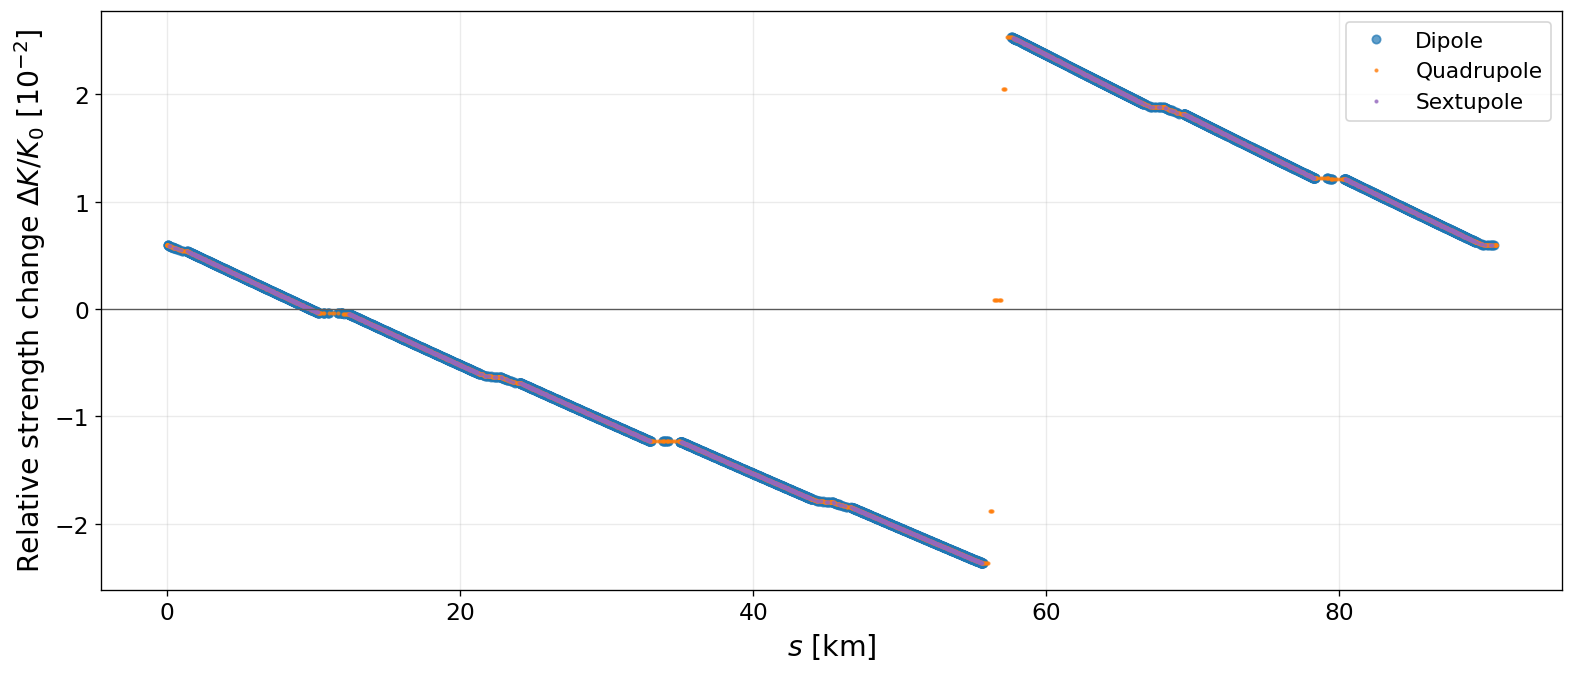

Saved: figures/ideal_taper_relative_strength_correction.png


In [ ]:
fig, ax = plt.subplots(figsize=(13, 5.5), layout="constrained")

for family, _, _, _ in families:
    selected = strengths[strengths["family"] == family]
    if family == "Dipole":
        ms = 10
    else:
        ms=3
    ax.plot(selected["s_m"] / 1e3, selected["delta_taper"] * 1e2, ".",
            ms=ms, alpha=0.7, color=colors[family], label=family)

ax.axhline(0.0, color="0.35", lw=0.8)
ax.set_xlabel(r"$s$ [km]")
ax.set_ylabel(r"Relative strength change $\Delta K/K_0$ [$10^{-2}$]")
ax.grid(True, alpha=0.25)
ax.legend(loc="best")

figure_path = FIGURE_DIR / "ideal_taper_relative_strength_correction.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {figure_path}")


In [ ]:
def rms(values):
    values = np.asarray(values, dtype=float)
    return float(np.sqrt(np.mean(values**2)))

# Interpolate only if the two Twiss tables do not use exactly the same s grid.
x_ideal_on_no = np.interp(twiss_no_taper.s, twiss_ideal.s, twiss_ideal.x)
y_ideal_on_no = np.interp(twiss_no_taper.s, twiss_ideal.s, twiss_ideal.y)

dx_um = (np.asarray(twiss_no_taper.x) - x_ideal_on_no) * 1e6
dy_um = (np.asarray(twiss_no_taper.y) - y_ideal_on_no) * 1e6

print("Orbit difference: no tapering minus ideal tapering")
print(f"  horizontal RMS = {rms(dx_um):.6g} um")
print(f"  horizontal max = {np.max(np.abs(dx_um)):.6g} um")
print(f"  vertical RMS   = {rms(dy_um):.6g} um")
print(f"  vertical max   = {np.max(np.abs(dy_um)):.6g} um")

print("Absolute orbit after ideal tapering ")
print(f"  horizontal RMS = {rms(np.asarray(twiss_ideal.x) * 1e6):.6g} um")
print(f"  horizontal max = {np.max(np.abs(np.asarray(twiss_ideal.x) * 1e6)):.6g} um")
print(f"  vertical RMS   = {rms(np.asarray(twiss_ideal.y) * 1e6):.6g} um")
print(f"  vertical max   = {np.max(np.abs(np.asarray(twiss_ideal.y) * 1e6)):.6g} um")

print("\nLargest ideal strength correction")
for family, _, change_label, scale in families:
    selected = strengths[strengths["family"] == family]
    index = selected["strength_change"].abs().idxmax()
    row = selected.loc[index]
    print(
        f"  {family:10s}: {row['name']}, "
        f"delta_taper={row['delta_taper']:.6g}, "
        f"change={row['strength_change'] * scale:.6g} "
        f"({change_label.replace('$', '')})"
    )

strengths.to_csv("no_taper_vs_ideal_taper_strengths.csv", index=False)
print("\nSaved numerical table: no_taper_vs_ideal_taper_strengths.csv")


Orbit difference: no tapering minus ideal tapering
  horizontal RMS = 2301.37 um
  horizontal max = 17138.7 um
  vertical RMS   = 3.95554 um
  vertical max   = 252.905 um
Absolute orbit after ideal tapering 
  horizontal RMS = 1.23551 um
  horizontal max = 8.4211 um
  vertical RMS   = 0.000420276 um
  vertical max   = 0.0236399 um

Largest ideal strength correction
  Dipole    : b7ra.2, delta_taper=-0.0184443, change=-72.8571 (\Delta(B\ell) [mT m])
  Quadrupole: qd0bl.2, delta_taper=0.0187949, change=-1966.5 (\Delta(G\ell) [mT])
  Sextupole : sdy2l.8, delta_taper=0.0188341, change=-11678.7 (\Delta(B''\ell) [mT/m])

Saved numerical table: no_taper_vs_ideal_taper_strengths.csv
